# Lab 4: Principal Components, Factors and the Sparse-Dense Debate

**ECON5129 Statistical Machine Learning** &middot; Adam Smith Business School, University of Glasgow

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/korobilis/ECON5129-labs/blob/main/solutions/lab04_factors_solutions.ipynb)

This lab accompanies Lecture 4. By the end of the session you should be able to:

1. Compute principal components from the singular value decomposition and interpret the loadings.
2. Choose the number of factors with an information criterion rather than by eye.
3. Show that principal components regression and ridge shrink the same directions, one abruptly and the other smoothly.
4. Estimate probabilistic PCA and explain what the noise variance parameter buys you.
5. Construct simulated economies that are genuinely sparse and genuinely dense, and demonstrate that the winning estimator differs between them.
6. Ask which of the two the FRED-MD panel resembles, and give a defensible answer.

**Plan for the session**

| Time | Part |
|---|---|
| 0:00 - 0:30 | Part 1. Principal components of the US economy |
| 0:30 - 0:45 | Part 2. How many factors? |
| 0:45 - 1:10 | Part 3. PCA and ridge as two views of one idea |
| 1:10 - 1:25 | Part 4. Probabilistic PCA |
| 1:25 - 2:00 | Part 5. Sparse or dense? |

## Setup

In [1]:
import os
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/korobilis/ECON5129-labs/main"

if not os.path.exists("econ5129_utils.py"):
    urllib.request.urlretrieve(f"{REPO_RAW}/econ5129_utils.py", "econ5129_utils.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import econ5129_utils as e5

e5.set_style()
rng = np.random.default_rng(5129)

## Part 1. Principal components of the US economy

The factor model asserts that a large panel is driven by a small number of common forces,

$$ x_{it} = \boldsymbol{\lambda}_i' \mathbf{f}_t + e_{it}, \qquad i = 1, \dots, N, \quad t = 1, \dots, T, $$

where $\mathbf{f}_t$ is a vector of $q$ factors and $\boldsymbol{\lambda}_i$ the loadings of series $i$. Principal components estimate both by least squares, which for this problem means a singular value decomposition.

Standardisation is not optional here. Principal components maximise variance, so without it the answer is determined by the units in which each series happens to be measured.

In [2]:
data, codes = e5.load_fredmd()
transformed = e5.fredmd_transform(data, codes).loc["1960-01":"2019-12"]
panel = transformed.loc[:, transformed.notna().all(axis=0)]

X = (panel - panel.mean()) / panel.std()
X_mat = X.to_numpy()
T, N = X_mat.shape
print(f"T = {T} months, N = {N} series")

U, d, Vt = np.linalg.svd(X_mat, full_matrices=False)
variance_share = d ** 2 / np.sum(d ** 2)

factors = U * d                      # T x N, the estimated factors
loadings = Vt.T                      # N x N, the estimated loadings

T = 720 months, N = 121 series


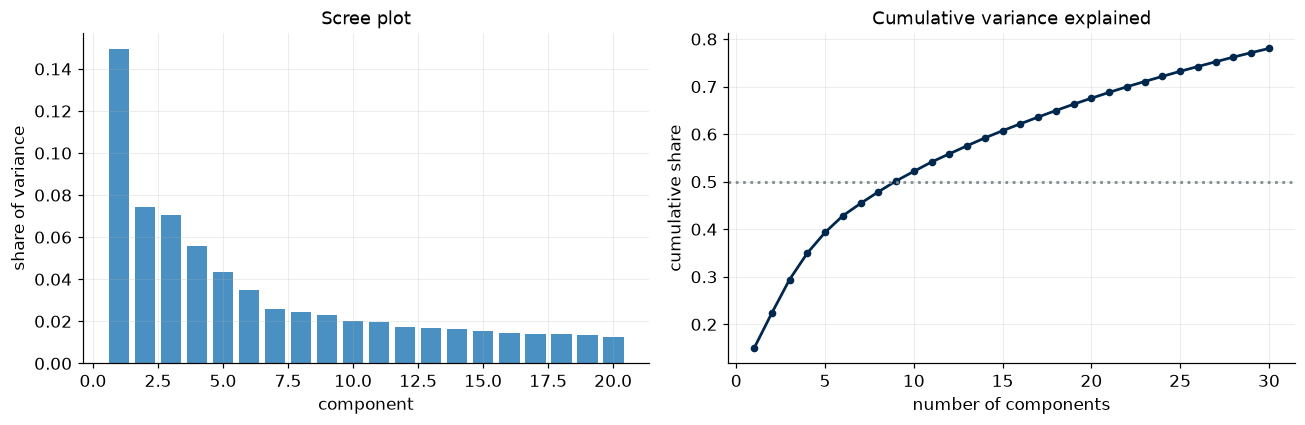

first component explains 14.9% of total variance
first eight explain 47.9%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(1, 21), variance_share[:20], color=e5.COLORS[1])
axes[0].set_xlabel("component")
axes[0].set_ylabel("share of variance")
axes[0].set_title("Scree plot")

axes[1].plot(np.arange(1, 31), np.cumsum(variance_share[:30]), marker="o", ms=4)
axes[1].axhline(0.5, color=e5.COLORS[6], ls=":")
axes[1].set_xlabel("number of components")
axes[1].set_ylabel("cumulative share")
axes[1].set_title("Cumulative variance explained")
fig.tight_layout()
plt.show()

print(f"first component explains {variance_share[0]:.1%} of total variance")
print(f"first eight explain {variance_share[:8].sum():.1%}")

A single component accounts for a substantial share of the variation in 120-odd series that measure very different things. That is the empirical content of the factor model.

What is the first factor? Look at which series load on it most heavily.

In [4]:
first = pd.Series(loadings[:, 0], index=panel.columns).sort_values()
print("Largest negative loadings:")
print(first.head(8).round(3).to_string())
print("\nLargest positive loadings:")
print(first.tail(8).round(3).to_string())

Largest negative loadings:
UNRATE      -0.131
UEMP15OV    -0.101
ISRATIOx    -0.097
CLAIMSx     -0.094
UEMP27OV    -0.076
UEMP15T26   -0.070
UEMP5TO14   -0.066
BAAFFM      -0.044

Largest positive loadings:
CUMFNS       0.183
DMANEMP      0.183
IPFPNSS      0.186
MANEMP       0.189
INDPRO       0.193
USGOOD       0.197
IPMANSICS    0.197
PAYEMS       0.197


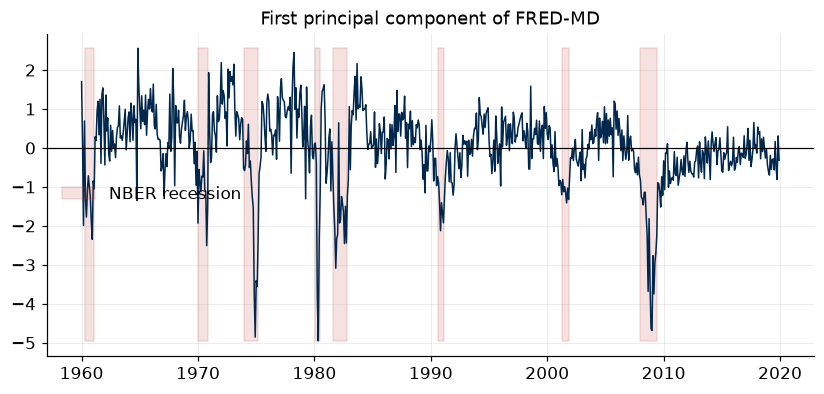

In [5]:
recession = e5.load_usrec().reindex(panel.index).to_numpy() == 1.0
f1 = factors[:, 0] / np.std(factors[:, 0])

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(panel.index, f1, color=e5.COLORS[0], lw=1.0)
ax.fill_between(panel.index, f1.min(), f1.max(), where=recession,
                color=e5.COLORS[2], alpha=0.15, label="NBER recession")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("First principal component of FRED-MD")
ax.legend()
plt.show()

### Exercise 1

The first factor has an obvious interpretation. The others are less obvious and more interesting.

1. Plot factors two, three and four against time with recessions shaded.
2. For each, list the eight series with the largest absolute loadings.
3. Propose an economic label for each factor. Prices, interest rates, housing and labour market slack are the usual candidates.

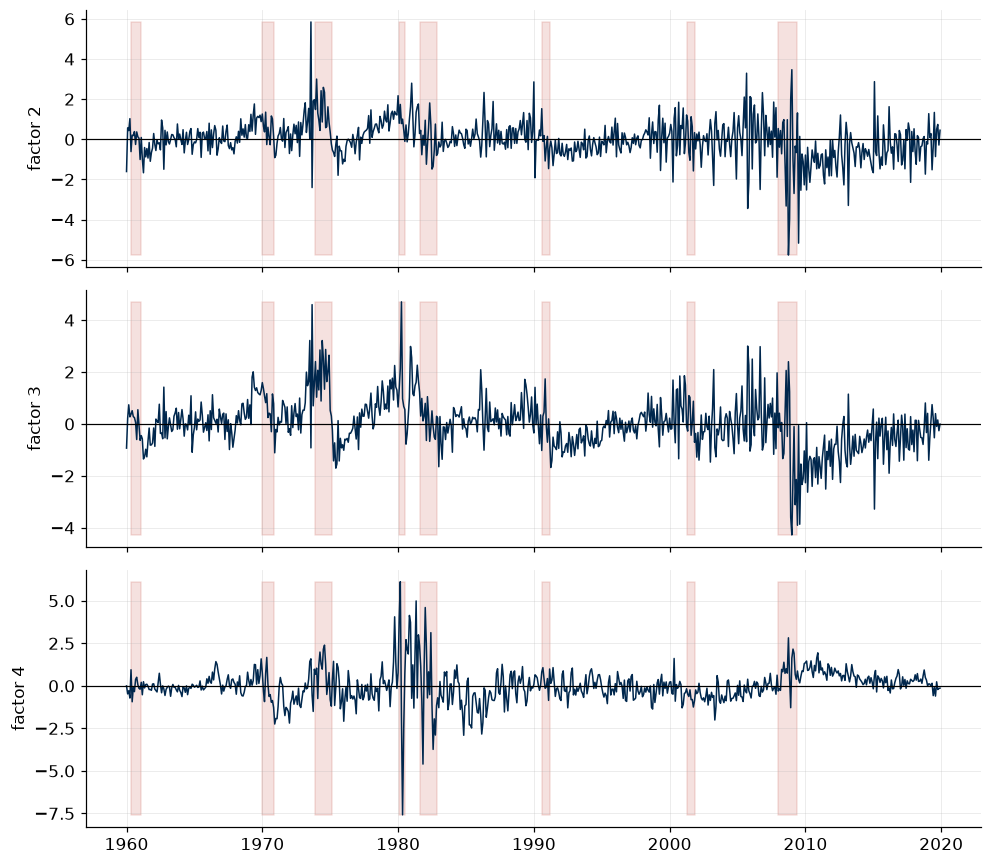

factor 2: CUSR0000SAC, DNDGRG3M086SBEA, CUSR0000SA0L2, CPIAUCSL, CUSR0000SA0L5, PCEPI, CPITRNSL, CPIULFSL
factor 3: AAAFFM, T10YFFM, BAAFFM, T5YFFM, TB3SMFFM, TB6SMFFM, CUSR0000SAC, DNDGRG3M086SBEA
factor 4: GS1, GS5, TB6MS, AAA, GS10, BAA, CP3Mx, TB3MS


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

for k, ax in zip([1, 2, 3], axes):
    f = factors[:, k] / np.std(factors[:, k])
    ax.plot(panel.index, f, color=e5.COLORS[0], lw=1.0)
    ax.fill_between(panel.index, f.min(), f.max(), where=recession,
                    color=e5.COLORS[2], alpha=0.15)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel(f"factor {k + 1}")
fig.tight_layout()
plt.show()

for k in [1, 2, 3]:
    top = pd.Series(loadings[:, k], index=panel.columns).abs().sort_values(ascending=False)
    print(f"factor {k + 1}: " + ", ".join(top.head(8).index))

## Part 2. How many factors?

The scree plot rarely shows a clean break. Bai and Ng (2002) turn the question into model selection, choosing $q$ to minimise

$$ IC_{p2}(q) = \log V(q) + q \left(\frac{N + T}{NT}\right) \log\left(\min(N, T)\right), $$

where $V(q)$ is the average residual variance after removing $q$ factors. The first term falls with $q$ and the second rises.

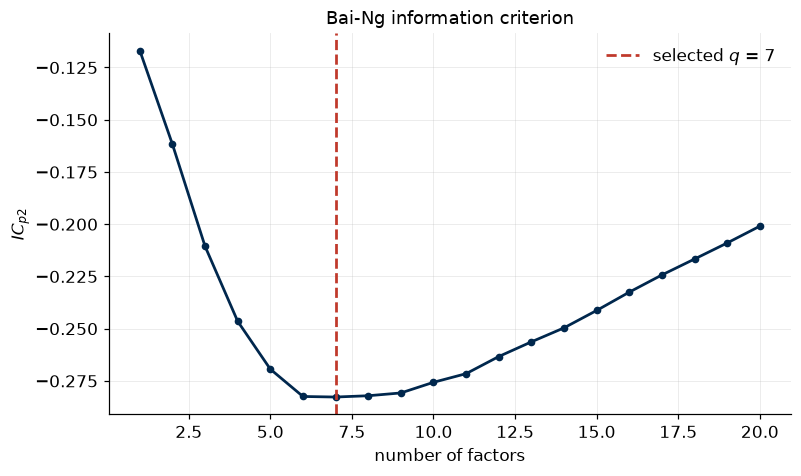

In [7]:
def bai_ng_ic(X_mat, q_max=20):
    """Bai-Ng ICp2 criterion across candidate numbers of factors."""
    T, N = X_mat.shape
    U, d, Vt = np.linalg.svd(X_mat, full_matrices=False)
    penalty_scale = ((N + T) / (N * T)) * np.log(min(N, T))

    values = []
    for q in range(1, q_max + 1):
        fitted = (U[:, :q] * d[:q]) @ Vt[:q]
        v_q = np.mean((X_mat - fitted) ** 2)
        values.append(np.log(v_q) + q * penalty_scale)
    return np.array(values)


ic = bai_ng_ic(X_mat, q_max=20)
q_hat = int(np.argmin(ic)) + 1

fig, ax = plt.subplots()
ax.plot(np.arange(1, 21), ic, marker="o", ms=4)
ax.axvline(q_hat, color=e5.COLORS[2], ls="--", label=f"selected $q$ = {q_hat}")
ax.set_xlabel("number of factors")
ax.set_ylabel("$IC_{p2}$")
ax.set_title("Bai-Ng information criterion")
ax.legend()
plt.show()

## Part 3. PCA and ridge as two views of one idea

Principal components regression keeps the first $q$ directions and discards the rest. Ridge keeps all of them but downweights each by $d_j^2/(d_j^2 + \lambda)$. Plotted together, the difference is a step function against a smooth one.

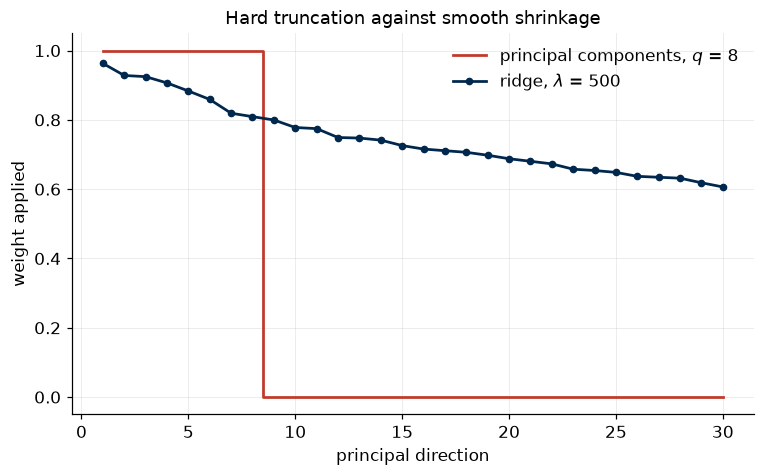

In [8]:
lam = 500.0
q_keep = 8

pcr_factor = np.zeros(N)
pcr_factor[:q_keep] = 1.0
ridge_factor = d ** 2 / (d ** 2 + lam)

fig, ax = plt.subplots()
ax.step(np.arange(1, 31), pcr_factor[:30], where="mid", color=e5.COLORS[2],
        label=f"principal components, $q$ = {q_keep}")
ax.plot(np.arange(1, 31), ridge_factor[:30], marker="o", ms=4, color=e5.COLORS[0],
        label=f"ridge, $\\lambda$ = {lam:g}")
ax.set_xlabel("principal direction")
ax.set_ylabel("weight applied")
ax.set_title("Hard truncation against smooth shrinkage")
ax.legend()
plt.show()

Both estimators believe the same thing: directions in which the predictors vary little are directions in which the coefficient is poorly estimated, so they should be trusted less. They differ only in how abruptly they act on that belief.

Now put them to work. The forecasting problem is the one from Lab 3: the monthly change in unemployment, one month ahead.

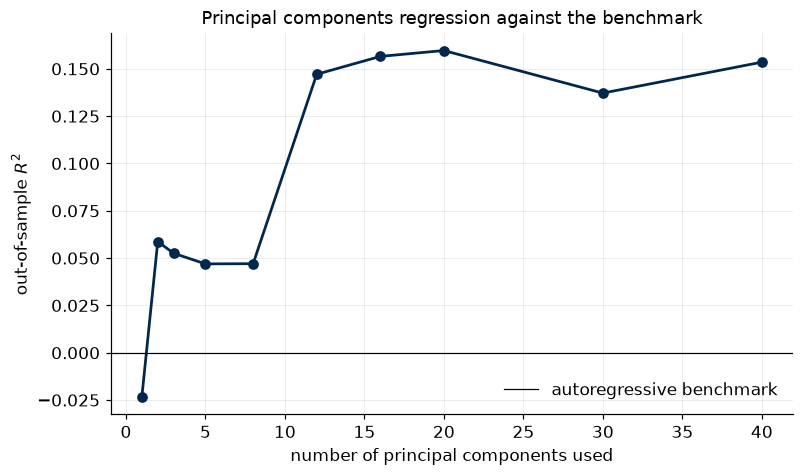

In [9]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import TimeSeriesSplit

dataset = e5.build_forecast_dataset(data, codes, target="UNRATE", horizon=1, n_lags=3)
Xf, yf, dates = dataset["X"], dataset["y"], dataset["dates"]

split = int(0.7 * len(yf))
Z_tr, Z_te, _, _ = e5.standardise(Xf[:split], Xf[split:])
y_tr, y_te = yf[:split], yf[split:]
y_mean = y_tr.mean()

ar_cols = [i for i, name in enumerate(dataset["names"]) if name.startswith("UNRATE.")]
b_ar, *_ = np.linalg.lstsq(np.column_stack([np.ones(split), Xf[:split, ar_cols]]), y_tr, rcond=None)
bench = np.column_stack([np.ones(len(y_te)), Xf[split:, ar_cols]]) @ b_ar


def pcr_forecast(Z_tr, y_tr, Z_te, q):
    """Principal components regression using training-sample directions only."""
    U_tr, d_tr, Vt_tr = np.linalg.svd(Z_tr, full_matrices=False)
    F_tr = Z_tr @ Vt_tr[:q].T
    F_te = Z_te @ Vt_tr[:q].T
    coef, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(y_tr)), F_tr]), y_tr, rcond=None)
    return np.column_stack([np.ones(len(F_te)), F_te]) @ coef


q_grid = [1, 2, 3, 5, 8, 12, 16, 20, 30, 40]
pcr_scores = [e5.oos_r2(y_te, pcr_forecast(Z_tr, y_tr, Z_te, q), benchmark=bench) for q in q_grid]

fig, ax = plt.subplots()
ax.plot(q_grid, pcr_scores, marker="o")
ax.axhline(0, color="black", lw=0.8, label="autoregressive benchmark")
ax.set_xlabel("number of principal components used")
ax.set_ylabel("out-of-sample $R^2$")
ax.set_title("Principal components regression against the benchmark")
ax.legend()
plt.show()

### Exercise 2

Compare the three shrinkage philosophies on identical footing.

1. Fit ridge and the LASSO with time series cross-validation on the training sample.
2. Select the number of principal components by the same cross-validation scheme rather than by looking at the test set.
3. Report out-of-sample $R^2$ against the autoregressive benchmark for all three, plus the number of predictors each effectively uses.

Which does best, and by how much? Note how close ridge and the LASSO are despite using 363 and roughly 30 predictors respectively.

In [10]:
tscv = TimeSeriesSplit(n_splits=5)
alpha_grid = np.logspace(-4, 1, 60)

cv_scores = []
for q in q_grid:
    fold_errors = []
    for tr_idx, va_idx in tscv.split(Z_tr):
        pred = pcr_forecast(Z_tr[tr_idx], y_tr[tr_idx], Z_tr[va_idx], q)
        fold_errors.append(e5.mse(y_tr[va_idx], pred))
    cv_scores.append(np.mean(fold_errors))

q_cv = q_grid[int(np.argmin(cv_scores))]

ridge = RidgeCV(alphas=np.logspace(0, 7, 50), cv=tscv).fit(Z_tr, y_tr - y_mean)
lasso = LassoCV(alphas=alpha_grid, cv=tscv, max_iter=50000).fit(Z_tr, y_tr - y_mean)

summary = pd.DataFrame([
    {"model": f"principal components ($q$ = {q_cv})",
     "out-of-sample $R^2$": e5.oos_r2(y_te, pcr_forecast(Z_tr, y_tr, Z_te, q_cv), bench),
     "predictors used": q_cv},
    {"model": "ridge",
     "out-of-sample $R^2$": e5.oos_r2(y_te, ridge.predict(Z_te) + y_mean, bench),
     "predictors used": Z_tr.shape[1]},
    {"model": "LASSO",
     "out-of-sample $R^2$": e5.oos_r2(y_te, lasso.predict(Z_te) + y_mean, bench),
     "predictors used": int(np.sum(lasso.coef_ != 0))},
]).set_index("model")

print(summary.round(4))

                                out-of-sample $R^2$  predictors used
model                                                               
principal components ($q$ = 2)               0.0587                2
ridge                                        0.1983              363
LASSO                                        0.1856               28


## Part 4. Probabilistic PCA

Ordinary PCA is an algorithm. Probabilistic PCA is a model,

$$ \mathbf{x}_t = \mathbf{W}\mathbf{f}_t + \boldsymbol{\varepsilon}_t, \qquad \mathbf{f}_t \sim N(\mathbf{0}, \mathbf{I}_q), \qquad \boldsymbol{\varepsilon}_t \sim N(\mathbf{0}, \sigma^2 \mathbf{I}), $$

with a likelihood, and therefore standard errors, model comparison, and a principled way to handle missing data. Its maximum likelihood solution is available in closed form: the loadings come from the leading eigenvectors, and the noise variance is the average of the eigenvalues that were discarded,

$$ \widehat{\sigma}^2 = \frac{1}{N - q}\sum_{j=q+1}^{N} \ell_j . $$

In [11]:
def probabilistic_pca(X_mat, q):
    """Maximum likelihood probabilistic PCA (Tipping and Bishop, 1999)."""
    T = X_mat.shape[0]
    S_eigs = np.linalg.svd(X_mat, compute_uv=False) ** 2 / T
    _, _, Vt = np.linalg.svd(X_mat, full_matrices=False)

    sigma2 = np.mean(S_eigs[q:])
    W = Vt[:q].T * np.sqrt(np.maximum(S_eigs[:q] - sigma2, 0.0))
    return W, sigma2, S_eigs


W, sigma2_hat, eigenvalues = probabilistic_pca(X_mat, q=q_hat)

print(f"q = {q_hat} factors")
print(f"estimated noise variance : {sigma2_hat:.4f}")
print(f"share of variance treated as idiosyncratic: {sigma2_hat * N / eigenvalues.sum():.1%}")

q = 7 factors
estimated noise variance : 0.5786
share of variance treated as idiosyncratic: 57.9%


The noise variance is what ordinary PCA lacks. It tells you how much of each series the factor structure is not even trying to explain, and it is what makes the model usable when observations are missing, which in real-time macroeconomic data they always are.

### Exercise 3

Probabilistic PCA implies a likelihood, so the number of factors can be chosen by comparing likelihoods rather than by an ad hoc criterion.

The log-likelihood of the model at the maximum is

$$ \ell(q) = -\frac{T}{2}\left[ N \log(2\pi) + \sum_{j=1}^{q} \log \ell_j + (N - q)\log \widehat{\sigma}^2 + N \right] . $$

1. Write a function returning this log-likelihood for a given $q$.
2. Compute the Bayesian information criterion, $-2\ell(q) + k_q \log T$, where the number of free parameters is $k_q = Nq - q(q-1)/2 + 1$.
3. Plot it against $q$ and compare the selected number of factors with the Bai-Ng answer from Part 2.

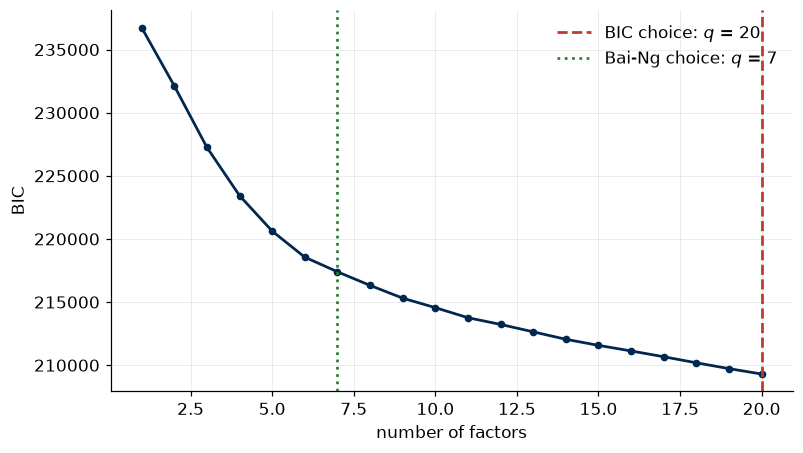

In [12]:
def ppca_loglik(eigenvalues, q, T, N):
    """Maximised log-likelihood of probabilistic PCA with q factors."""
    sigma2 = np.mean(eigenvalues[q:])
    return -0.5 * T * (N * np.log(2 * np.pi) + np.sum(np.log(eigenvalues[:q]))
                       + (N - q) * np.log(sigma2) + N)


q_range = np.arange(1, 21)
bic = []
for q in q_range:
    ll = ppca_loglik(eigenvalues, q, T, N)
    k_q = N * q - q * (q - 1) / 2 + 1
    bic.append(-2 * ll + k_q * np.log(T))

fig, ax = plt.subplots()
ax.plot(q_range, bic, marker="o", ms=4)
ax.axvline(q_range[int(np.argmin(bic))], color=e5.COLORS[2], ls="--",
           label=f"BIC choice: $q$ = {q_range[int(np.argmin(bic))]}")
ax.axvline(q_hat, color=e5.COLORS[4], ls=":", label=f"Bai-Ng choice: $q$ = {q_hat}")
ax.set_xlabel("number of factors")
ax.set_ylabel("BIC")
ax.legend()
plt.show()

## Part 5. Sparse or dense?

The two halves of this lecture disagree. The LASSO assumes a few predictors matter and the rest are exactly zero. Factor models and ridge assume everything matters a little. These are different beliefs about the world, and which estimator wins is an empirical question rather than a matter of taste.

We settle it first where the truth is known, by building both economies.

In [13]:
def sparse_economy(n=300, p=200, seed=0):
    """Five predictors matter; the rest are exactly irrelevant."""
    gen = np.random.default_rng(seed)
    X = gen.normal(size=(n, p))
    beta = np.zeros(p)
    beta[gen.choice(p, 5, replace=False)] = 2.0
    y = X @ beta + np.std(X @ beta) / np.sqrt(3.0) * gen.normal(size=n)
    return X, y


def dense_economy(n=300, p=200, seed=0):
    """Every predictor matters a little, with no zero coefficients."""
    gen = np.random.default_rng(seed)
    X = gen.normal(size=(n, p))
    beta = gen.normal(scale=1.0 / np.sqrt(p), size=p)
    y = X @ beta + np.std(X @ beta) / np.sqrt(3.0) * gen.normal(size=n)
    return X, y


from sklearn.linear_model import Ridge, Lasso

def compare_estimators(X, y, n_train=150):
    """Out-of-sample MSE of ridge, LASSO and principal components regression."""
    Xtr, Xte, ytr, yte = X[:n_train], X[n_train:], y[:n_train], y[n_train:]
    Ztr, Zte, _, _ = e5.standardise(Xtr, Xte)
    centred = ytr - ytr.mean()

    out = {}
    tscv_local = TimeSeriesSplit(n_splits=5)
    out["ridge"] = e5.mse(yte, RidgeCV(alphas=np.logspace(-2, 5, 40), cv=tscv_local)
                          .fit(Ztr, centred).predict(Zte) + ytr.mean())
    out["LASSO"] = e5.mse(yte, LassoCV(alphas=np.logspace(-4, 1, 50), cv=tscv_local,
                                       max_iter=50000)
                          .fit(Ztr, centred).predict(Zte) + ytr.mean())
    best = min(e5.mse(yte, pcr_forecast(Ztr, ytr, Zte, q)) for q in [1, 2, 5, 10, 20, 40])
    out["principal components"] = best
    return out


rows = []
for label, builder in [("sparse economy", sparse_economy), ("dense economy", dense_economy)]:
    scores = [compare_estimators(*builder(seed=s)) for s in range(5)]
    row = {k: np.mean([s[k] for s in scores]) for k in scores[0]}
    row["economy"] = label
    rows.append(row)

print(pd.DataFrame(rows).set_index("economy").round(4))

                  ridge   LASSO  principal components
economy                                              
sparse economy  16.7772  7.5027               21.8140
dense economy    0.7500  1.0099                1.0047


The ranking flips. Neither estimator is universally better, and an argument about which method is "right" without reference to the data generating process is an argument about nothing.

### Exercise 4

So which does the US economy resemble?

Two pieces of evidence are available to you from this lab and the last.

1. The LASSO fitted to the unemployment forecasting problem selects a specific number of predictors. Report it, and report how much of the total variation in the panel the first eight principal components explain.
2. Refit the LASSO after replacing the 363 raw predictors with the first eight estimated factors, and compare its out-of-sample performance with the LASSO on raw predictors.
3. Write two or three sentences arguing for whichever description you find more convincing, citing the numbers you produced.

There is no single correct answer here. There is a range of defensible ones, and the literature contains several.

In [14]:
U_tr, d_tr, Vt_tr = np.linalg.svd(Z_tr, full_matrices=False)
q_use = 8
F_tr = Z_tr @ Vt_tr[:q_use].T
F_te = Z_te @ Vt_tr[:q_use].T

lasso_factors = LassoCV(alphas=alpha_grid, cv=tscv, max_iter=50000).fit(F_tr, y_tr - y_mean)
lasso_raw = LassoCV(alphas=alpha_grid, cv=tscv, max_iter=50000).fit(Z_tr, y_tr - y_mean)

print(pd.DataFrame([
    {"specification": "LASSO on 363 raw predictors",
     "out-of-sample $R^2$": e5.oos_r2(y_te, lasso_raw.predict(Z_te) + y_mean, bench),
     "nonzero": int(np.sum(lasso_raw.coef_ != 0))},
    {"specification": f"LASSO on {q_use} estimated factors",
     "out-of-sample $R^2$": e5.oos_r2(y_te, lasso_factors.predict(F_te) + y_mean, bench),
     "nonzero": int(np.sum(lasso_factors.coef_ != 0))},
]).set_index("specification").round(4))

print(f"\nfirst eight components explain {variance_share[:8].sum():.1%} of panel variance")

                              out-of-sample $R^2$  nonzero
specification                                             
LASSO on 363 raw predictors                0.1856       28
LASSO on 8 estimated factors               0.0309        2

first eight components explain 47.9% of panel variance


## Take-home challenges

1. **Rotational indeterminacy.** Factors are identified only up to an invertible linear transformation. Rotate the estimated factors by an arbitrary orthogonal matrix, refit the forecasting regression, and confirm that the forecasts are unchanged while the loadings are entirely different. What does this imply about interpreting individual factors?

2. **Missing data.** Delete 10% of the entries in the panel at random and estimate the factors with an expectation-maximisation loop: fill the gaps with the current fitted values, recompute the singular value decomposition, repeat. Compare the recovered factors with the ones estimated on the complete panel.

3. **Factor-augmented autoregression.** Combine three lags of the target with the first eight factors in a single regression, the standard FAVAR forecasting specification. Does it beat the LASSO on raw predictors?

4. **Stability.** Re-estimate the factors on 1960-1989 and on 1990-2019 separately. Do the loadings on the first factor look the same in both halves?

---

**Next**: Lecture 5 drops the assumption that the conditional mean is linear. Lab 5 builds kernel smoothers, splines and Gaussian processes, and asks what "effective degrees of freedom" means when there are no coefficients to count.